#Auto 1111 SDK
Auto 1111 SDK is the first Python client for the Automatic 1111 Stable Diffusion Web UI. It allows you run the functionality of the Web UI but in a light-weight, modular, fast Python library, making it very easy to develop applications on it. Check it out at https://github.com/saketh12/Auto1111SDK

We are not banned on free Colab because we are just a python library - we are not launching any Gradio app. We're aiming to make stable diffusion free and accessible for all!

In [1]:
#@markdown ##**Install library**
!python -m pip install pip --upgrade
!python -m pip install ipython
!python -m pip install ipykernel ipywidgets notebook
!python -m pip install auto1111sdk



  Using cached httpx-0.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpcore-1.0.2-py3-none-any.whl.metadata (20 kB)
  Using cached h11-0.14.0-py3-none-any.whl (58 kB)
Using cached httpx-0.26.0-py3-none-any.whl (75 kB)
Using cached httpcore-1.0.2-py3-none-any.whl (76 kB)
  Attempting uninstall: h11
    Found existing installation: h11 0.12.0
    Uninstalling h11-0.12.0:
      Successfully uninstalled h11-0.12.0
  Attempting uninstall: httpcore
    Found existing installation: httpcore 0.15.0
    Uninstalling httpcore-0.15.0:
      Successfully uninstalled httpcore-0.15.0
  Attempting uninstall: httpx
    Found existing installation: httpx 0.24.1
    Uninstalling httpx-0.24.1:
      Successfully uninstalled httpx-0.24.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
auto1111sdk 0.0.92 requires httpcore==0.15, but you have httpcore 1.0.2 which is incompatible.
auto1111sdk 0.0.92 requires httpx==0.24.1, but you have httpx 0.26.0 which is incompatible.


In [2]:
import os
# import sys
from IPython.display import display
import requests
from io import BytesIO

from auto1111sdk import civit_download
from auto1111sdk import download_realesrgan
from auto1111sdk import RealEsrganPipeline
from auto1111sdk import StableDiffusionPipeline
# from auto1111sdk import EsrganPipeline
from PIL import Image

#@markdown ##**Civit Download:**
civit_url = 'https://civitai.com/models/4384/dreamshaper' #@param{type: 'string'}
model_path = 'dreamshaper.safetensors'

if not os.path.exists(model_path):
    print(f'downloading {model_path} from {civit_url}')
    civit_download(civit_url, model_path)
else:
    print(f'using model {model_path}')


usage: ipykernel_launcher.py [-h] [--update-all-extensions]
                             [--skip-python-version-check]
                             [--skip-torch-cuda-test] [--reinstall-xformers]
                             [--reinstall-torch] [--update-check]
                             [--test-server] [--log-startup]
                             [--skip-prepare-environment] [--skip-install]
                             [--dump-sysinfo] [--loglevel LOGLEVEL]
                             [--do-not-download-clip] [--data-dir DATA_DIR]
                             [--config CONFIG] [--ckpt CKPT]
                             [--ckpt-dir CKPT_DIR] [--vae-dir VAE_DIR]
                             [--gfpgan-dir GFPGAN_DIR]
                             [--gfpgan-model GFPGAN_MODEL] [--no-half]
                             [--no-half-vae] [--no-progressbar-hiding]
                             [--max-batch-count MAX_BATCH_COUNT]
                             [--embeddings-dir EMBEDDINGS_DIR]
 

SystemExit: 2

c:\Users\mgua\venv_py_stable\lib\site-packages\IPython\core\interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

Applying attention optimization: Doggettx... done.


  0%|          | 0/20 [00:00<?, ?it/s]


Total progress: 0it [00:00, ?it/s]
Total progress: 2it [00:00,  4.58it/s]
Total progress: 3it [00:00,  3.19it/s]
Total progress: 4it [00:01,  2.75it/s]
Total progress: 5it [00:01,  2.55it/s]
Total progress: 6it [00:02,  2.44it/s]
Total progress: 7it [00:02,  2.37it/s]
Total progress: 8it [00:03,  2.33it/s]
Total progress: 9it [00:03,  2.30it/s]
Total progress: 10it [00:04,  2.28it/s]
Total progress: 11it [00:04,  2.26it/s]
Total progress: 12it [00:04,  2.26it/s]
Total progress: 13it [00:05,  2.24it/s]
Total progress: 14it [00:05,  2.24it/s]
Total progress: 15it [00:06,  2.24it/s]
Total progress: 16it [00:06,  2.24it/s]
Total progress: 17it [00:07,  2.24it/s]
Total progress: 18it [00:07,  2.24it/s]
Total progress: 19it [00:08,  2.23it/s]
Total progress: 20it [00:09,  2.16it/s]


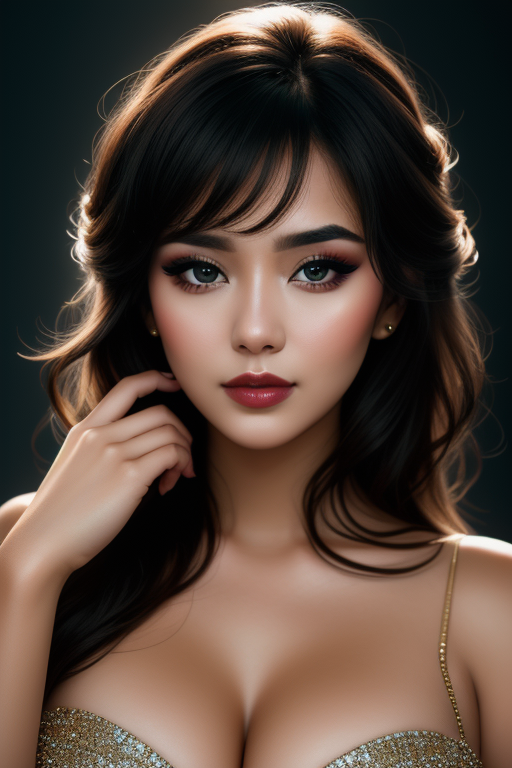

In [ ]:
#@title ##**Text to Image**

###################################Txt2Img##############################################
pipe = StableDiffusionPipeline(model_path)
prompt = "closeup portrait photo of beautiful 26 y.o woman, makeup, 8k uhd, high quality, dramatic, cinematic" #@param{type: 'string'}
negative_prompt = "(deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime), text, cropped, out of frame, worst quality, low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers, mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry, dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured, gross proportions, malformed limbs, missing arms, missing legs, extra arms, extra legs, fused fingers, too many fingers, long neck" #@param{type: 'string'}
num_images = 1 #@param{type: 'number'}
height = 768 #@param{type: 'number'}
width = 512 #@param{type: 'number'}
steps = 20 #@param{type: 'number'}
output_path = "txt2img.png" #@param{type: 'string'}
cfg_scale = 7.5 #@param{type: 'number'}
seed = -1 #@param{type: 'number'}
sampler_name ='Euler' #@param ["Euler a", "Euler", "LMS", "Heun", "DPM2", "DPM2 a", "DPM++ 2S a", "DPM++ 2M", "DPM fast", "DPM adaptive", "LMS Karras", "DPM2 Karras", "DPM2 a Karras", "DPM++ 2S a Karras", "DPM++ 2M Karras", "DDIM", "PLMS"]
output = pipe.generate_txt2img(num_images = num_images,
cfg_scale = cfg_scale, sampler_name = sampler_name, seed=seed, prompt = prompt, height = height, width = width, negative_prompt = negative_prompt, steps = steps)
output[0].save(output_path)
display(output[0])
del pipe

In [ ]:
#@title ##**Image to Image**

###################################Img2Img##############################################

pipe = StableDiffusionPipeline(model_path)
prompt = "closeup portrait photo of beautiful indian woman, 8k uhd, high quality, cinematic" #@param{type: 'string'}
negative_prompt = "(deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime), text, cropped, out of frame, worst quality, low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers, mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry, dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured, gross proportions, malformed limbs, missing arms, missing legs, extra arms, extra legs, fused fingers, too many fingers, long neck" #@param{type: 'string'}
num_images = 1 #@param{type: 'number'}
height = 768 #@param{type: 'number'}
width = 512 #@param{type: 'number'}
steps = 20 #@param{type: 'number'}
cfg_scale = 7.5 #@param{type: 'number'}
seed = -1 #@param{type: 'number'}
sampler_name ='Euler' #@param ["Euler a", "Euler", "LMS", "Heun", "DPM2", "DPM2 a", "DPM++ 2S a", "DPM++ 2M", "DPM fast", "DPM adaptive", "LMS Karras", "DPM2 Karras", "DPM2 a Karras", "DPM++ 2S a Karras", "DPM++ 2M Karras", "DDIM", "PLMS"]
denoising_strength = 0.75 #@param{type: 'number'}
output_path = "img2img.png" #@param{type: 'string'}
init_image_path = "txt2img.png" #@param{type: 'string'}
image = Image.open(init_image_path)
output = pipe.generate_img2img(init_image=image, cfg_scale = cfg_scale, denoising_strength = denoising_strength,
 seed=seed, num_images = num_images, prompt=prompt,sampler_name = sampler_name, negative_prompt = negative_prompt, steps = steps, height = height, width = width)
output[0].save(output_path)
display(output[0])
del pipe

In [ ]:
## Download model for inpainting/outpainting

#@markdown ##**Civit Download for Inpainting model:**
civit_inpaint_url = "https://civitai.com/models/4384?modelVersionId=131004" #@param{type: 'string'}
model_inpaint_path = "dreamshaper_8Inpainting.safetensors"

civit_download(civit_inpaint_url, model_inpaint_path)

In [ ]:
#@title ##**Outpainting:**

image_url = "https://flush-user-images.s3.us-east-2.amazonaws.com/photo.webp" #@param{type: 'string'}
response = requests.get(image_url)
init_image = Image.open(BytesIO(response.content))

####################################Outpainting#############################################

pipe_inpainting = StableDiffusionPipeline(model_inpaint_path)

prompt = "closeup portrait photo of beautiful 26 y.o woman, makeup, 8k uhd, high quality, dramatic, cinematic" #@param{type: 'string'}
negative_prompt = "(deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime), text, cropped, out of frame, worst quality, low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers, mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry, dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured, gross proportions, malformed limbs, missing arms, missing legs, extra arms, extra legs, fused fingers, too many fingers, long neck" #@param{type: 'string'}
steps = 20 #@param{type: 'number'}
cfg_scale = 7.5 #@param{type: 'number'}
seed = -1 #@param{type: 'number'}
pixels = 128 #@param{type: 'number'}
mask_blur = 4 #@param{type: 'number'}
sampler_name ='Euler' #@param ["Euler a", "Euler", "LMS", "Heun", "DPM2", "DPM2 a", "DPM++ 2S a", "DPM++ 2M", "DPM fast", "DPM adaptive", "LMS Karras", "DPM2 Karras", "DPM2 a Karras", "DPM++ 2S a Karras", "DPM++ 2M Karras", "DDIM", "PLMS"]
output_path = "outpainted.png" #@param{type: 'string'}
outpaint_left = True #@param{type: 'boolean'}
outpaint_right = False #@param{type: 'boolean'}
outpaint_up = False #@param{type: 'boolean'}
outpaint_down = False #@param{type: 'boolean'}
direction = []

if outpaint_left:
  direction.append("left")
if outpaint_right:
  direction.append("right")
if outpaint_up:
  direction.append("up")
if outpaint_down:
  direction.append("down")
output = pipe_inpainting.poor_mans_outpainting_img2img(cfg_scale = cfg_scale, mask_blur = mask_blur, seed=seed, sampler_name = sampler_name, pixels=pixels, steps=steps, prompt = prompt, direction=direction, negative_prompt=negative_prompt, init_image = init_image)
output[0].save(output_path)
display(output[0])
del pipe_inpainting

In [ ]:
#@title ##**Inpainting:**

####################################Inpainting##############################################
pipe_inpainting = StableDiffusionPipeline(model_inpaint_path)

prompt = "closeup portrait photo of beautiful 26 y.o woman, makeup, 8k uhd, high quality, dramatic, cinematic, ((green hair))" #@param{type: 'string'}
negative_prompt = "(deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime), text, cropped, out of frame, worst quality, low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers, mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry, dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured, gross proportions, malformed limbs, missing arms, missing legs, extra arms, extra legs, fused fingers, too many fingers, long neck" #@param{type: 'string'}

image_url = "https://flush-user-images.s3.us-east-2.amazonaws.com/photo.webp" #@param{type: 'string'}
response = requests.get(image_url)
init_image = Image.open(BytesIO(response.content))

mask = "https://flush-user-images.s3.us-east-2.amazonaws.com/mask.png" #@param{type: 'string'}
output_path = "inpainted.png" #@param{type: 'string'}

response = requests.get(mask)
mask = Image.open(BytesIO(response.content))

num_images = 1 #@param{type: 'number'}
inpaint_full_res_padding = 32 #@param{type: 'number'}

cfg_scale = 7.5 #@param{type: 'number'}
seed = -1 #@param{type: 'number'}
sampler_name ='Euler' #@param ["Euler a", "Euler", "LMS", "Heun", "DPM2", "DPM2 a", "DPM++ 2S a", "DPM++ 2M", "DPM fast", "DPM adaptive", "LMS Karras", "DPM2 Karras", "DPM2 a Karras", "DPM++ 2S a Karras", "DPM++ 2M Karras", "DDIM", "PLMS"]
denoising_strength = 0.75 #@param{type: 'number'}

output = pipe_inpainting.inpainting_img2img(cfg_scale = cfg_scale, seed=seed, denoising_strength = denoising_strength, sampler_name = sampler_name, num_images = num_images, inpaint_full_res_padding=inpaint_full_res_padding, mask = mask, init_image = init_image, prompt = prompt, negative_prompt = negative_prompt)
output[0].save(output_path)
display(output[0])
del pipe_inpainting

In [ ]:
#@title ##**Real Esrgan Download:**
r_model_id = "R-ESRGAN 4x+" #@param{type: 'string'}
r_model_path = "upscaler.pth"

download_realesrgan(r_model_id, r_model_path)

In [ ]:
#@markdown ####**Upscale with Real Esrgan:**
upscaler = RealEsrganPipeline(r_model_id, r_model_path)

image_url = "https://flush-user-images.s3.us-east-2.amazonaws.com/photo.webp" #@param{type: 'string'}
response = requests.get(image_url)
init_image = Image.open(BytesIO(response.content))

scale = 4 #@param{type: 'number'}
output_path = "upscaled.png" #@param{type: 'string'}

output = upscaler.upscale(img=init_image, scale=scale)

output.save(output_path)
display(output)
del upscaler